In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
roc_curve,
classification_report,
confusion_matrix
)

import pennylane as qml
from pennylane import numpy as pnp

np.random.seed(42)

In [46]:
df=pd.read_csv(
"creditcard.csv"
)

print(df.shape)

print(
df["Class"].value_counts()
)

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [91]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [48]:
fraud=df[
df.Class==1
]

normal=df[
df.Class==0
].sample(
len(fraud),
random_state=42
)

df_bal=pd.concat(
[fraud,normal]
).sample(
frac=1,
random_state=42
)

X=df_bal.drop(
"Class",
axis=1
)

y=df_bal["Class"].values

In [49]:
scaler=StandardScaler()

X=scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
X,
y,
test_size=0.30,
random_state=42,
stratify=y
)

print(
X_train.shape,
X_test.shape
)

(688, 30) (296, 30)


In [50]:
normal_train=X_train[
y_train==0
]

iso=IsolationForest(
n_estimators=50,
contamination=0.5,
random_state=42
)

iso.fit(
normal_train
)

pred_ml=iso.predict(
X_test
)

pred_ml=np.where(
pred_ml==-1,
1,
0
)

acc_ml=accuracy_score(
y_test,
pred_ml
)

print(
"Classical Accuracy:",
acc_ml
)

print(
classification_report(
y_test,
pred_ml
)
)

Classical Accuracy: 0.7162162162162162
              precision    recall  f1-score   support

           0       0.94      0.46      0.62       148
           1       0.64      0.97      0.77       148

    accuracy                           0.72       296
   macro avg       0.79      0.72      0.70       296
weighted avg       0.79      0.72      0.70       296



In [55]:
def run_qml(n_qubits):

    print(
    "\nRunning",
    n_qubits,
    "Qubits"
    )

    pca=PCA(
    n_components=n_qubits
    )

    Xtr=pca.fit_transform(
    X_train
    )

    Xte=pca.transform(
    X_test
    )


    # training size + epochs
    if n_qubits==4:

        Xsmall=Xtr[:150]

        ysmall=y_train[:150]

        lr=0.08

        epochs=20

        layers=2


    elif n_qubits==6:

        Xsmall=Xtr[:250]

        ysmall=y_train[:250]

        lr=0.06

        epochs=30

        layers=3


    else:

        Xsmall=Xtr[:350]

        ysmall=y_train[:350]

        lr=0.04

        epochs=40

        layers=3


    dev=qml.device(
    "default.qubit",
    wires=n_qubits
    )


    @qml.qnode(dev)
    def circuit(x,w):

        for i in range(n_qubits):

            qml.RY(
            x[i],
            wires=i
            )


        p=0

        for d in range(layers):

            for i in range(n_qubits):

                qml.RY(
                w[p],
                wires=i
                )

                p+=1


            for i in range(
            n_qubits-1
            ):

                qml.CNOT(
                wires=[i,i+1]
                )


            qml.CNOT(
            wires=[
            n_qubits-1,
            0
            ]
            )


        return qml.expval(
        qml.PauliZ(0)
        )


    # NOW works
    n_params=layers*n_qubits


    weights=pnp.random.randn(
    n_params,
    requires_grad=True
    )


    def loss(weights):

        preds=[]

        for i in range(
        len(Xsmall)
        ):

            val=circuit(
            Xsmall[i],
            weights
            )

            preds.append(
            (val+1)/2
            )


        preds=pnp.array(
        preds,
        requires_grad=True
        )

        yt=pnp.array(
        ysmall
        )

        return pnp.mean(
        (preds-yt)**2
        )


    opt=qml.AdamOptimizer(
    lr
    )

    loss_history=[]


    for e in range(
    epochs
    ):

        weights=opt.step(
        loss,
        weights
        )

        l=loss(weights)

        loss_history.append(l)

        print(
        "Epoch",
        e,
        "Loss",
        l
        )


    plt.plot(
    loss_history
    )

    plt.title(
    str(n_qubits)+
    " Qubit Loss"
    )

    plt.show()


    print(
    qml.draw(circuit)(
    Xsmall[0],
    weights
    )
    )


    scores=[]

    for x in Xte:

        val=circuit(
        x,
        weights
        )

        scores.append(
        (val+1)/2
        )


    # thresholds
    if n_qubits==4:
        th=0.50

    elif n_qubits==6:
        th=0.47

    else:
        th=0.44


    pred=(
    np.array(scores)>th
    ).astype(int)


    acc=accuracy_score(
    y_test,
    pred
    )

    roc=roc_auc_score(
    y_test,
    pred
    )

    pre=precision_score(
    y_test,
    pred
    )

    rec=recall_score(
    y_test,
    pred
    )

    f1=f1_score(
    y_test,
    pred
    )


    print(
    classification_report(
    y_test,
    pred
    )
    )


    return(
    acc,
    roc,
    pred,
    pre,
    rec,
    f1
    )


Running 4 Qubits
Epoch 0 Loss 0.19503186263546105
Epoch 1 Loss 0.1775728664239148
Epoch 2 Loss 0.1669862408875451
Epoch 3 Loss 0.16180212138447256
Epoch 4 Loss 0.1601489591649126
Epoch 5 Loss 0.16038590211513787
Epoch 6 Loss 0.16130398938779705
Epoch 7 Loss 0.16212048390375722
Epoch 8 Loss 0.1624114406858284
Epoch 9 Loss 0.16201737378284964
Epoch 10 Loss 0.16095691759691413
Epoch 11 Loss 0.15936569043151935
Epoch 12 Loss 0.15745521852805947
Epoch 13 Loss 0.15547965085792176
Epoch 14 Loss 0.15370069969712438
Epoch 15 Loss 0.15234670941981587
Epoch 16 Loss 0.1515677675695663
Epoch 17 Loss 0.15139561867296522
Epoch 18 Loss 0.15172513456040118
Epoch 19 Loss 0.15233803540446544


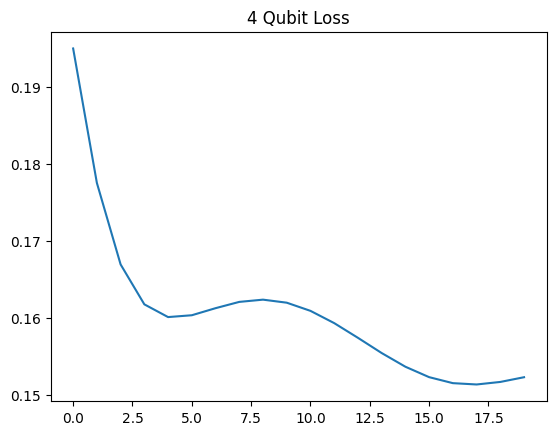

0: ──RY(2.30)───RY(-0.29)─╭●───────╭X──RY(-0.57)─╭●───────╭X─┤  <Z>
1: ──RY(-0.50)──RY(1.96)──╰X─╭●────│───RY(-0.61)─╰X─╭●────│──┤     
2: ──RY(-2.29)──RY(-0.13)────╰X─╭●─│───RY(-2.32)────╰X─╭●─│──┤     
3: ──RY(0.37)───RY(-1.16)───────╰X─╰●──RY(1.89)────────╰X─╰●─┤     
              precision    recall  f1-score   support

           0       0.69      1.00      0.82       148
           1       1.00      0.55      0.71       148

    accuracy                           0.77       296
   macro avg       0.84      0.77      0.76       296
weighted avg       0.84      0.77      0.76       296



In [56]:
acc4,roc4,p4,pre4,rec4,f14=run_qml(4)


Running 6 Qubits
Epoch 0 Loss 0.2519698586635523
Epoch 1 Loss 0.24022837454383675
Epoch 2 Loss 0.23322522127504236
Epoch 3 Loss 0.229324869671241
Epoch 4 Loss 0.2269063521925741
Epoch 5 Loss 0.2249115335304876
Epoch 6 Loss 0.22273438025197373
Epoch 7 Loss 0.2200469014347658
Epoch 8 Loss 0.21667360941640998
Epoch 9 Loss 0.2126111762307978
Epoch 10 Loss 0.2080460471897984
Epoch 11 Loss 0.20329493417700797
Epoch 12 Loss 0.1987134952084168
Epoch 13 Loss 0.1945906895207886
Epoch 14 Loss 0.19105700430129158
Epoch 15 Loss 0.18805789898928182
Epoch 16 Loss 0.18542516026389047
Epoch 17 Loss 0.18298948168321602
Epoch 18 Loss 0.180639117334505
Epoch 19 Loss 0.178314018340672
Epoch 20 Loss 0.17598184776906897
Epoch 21 Loss 0.1736195637651904
Epoch 22 Loss 0.17120775060485033
Epoch 23 Loss 0.16874562247830802
Epoch 24 Loss 0.16627652768609957
Epoch 25 Loss 0.16389661497795674
Epoch 26 Loss 0.1617299944808599
Epoch 27 Loss 0.15987785233729696
Epoch 28 Loss 0.15837061526460985
Epoch 29 Loss 0.157165

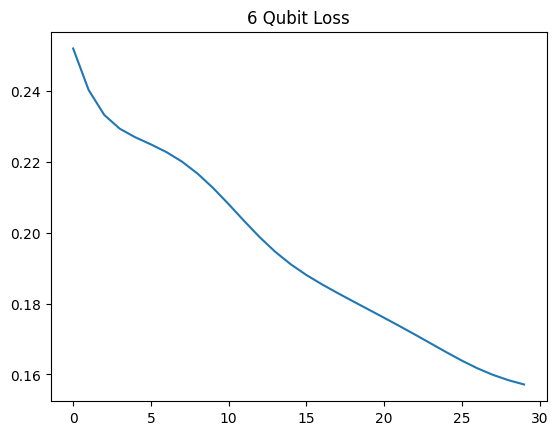

0: ──RY(2.30)───RY(-3.82)─╭●─────────────╭X──RY(0.47)──╭●─────────────╭X──RY(0.10)──╭●───────── ···
1: ──RY(-0.50)──RY(1.47)──╰X─╭●──────────│───RY(1.43)──╰X─╭●──────────│───RY(-0.13)─╰X─╭●────── ···
2: ──RY(-2.29)──RY(-0.33)────╰X─╭●───────│───RY(0.04)─────╰X─╭●───────│───RY(-0.27)────╰X─╭●─── ···
3: ──RY(0.37)───RY(-0.73)───────╰X─╭●────│───RY(1.47)────────╰X─╭●────│───RY(-0.15)───────╰X─╭● ···
4: ──RY(-0.38)──RY(-2.43)──────────╰X─╭●─│───RY(-0.26)──────────╰X─╭●─│───RY(-0.01)──────────╰X ···
5: ──RY(0.41)───RY(-0.01)─────────────╰X─╰●──RY(1.30)──────────────╰X─╰●──RY(-1.60)──────────── ···

0: ··· ────╭X─┤  <Z>
1: ··· ────│──┤     
2: ··· ────│──┤     
3: ··· ────│──┤     
4: ··· ─╭●─│──┤     
5: ··· ─╰X─╰●─┤     
              precision    recall  f1-score   support

           0       0.74      0.91      0.81       148
           1       0.88      0.68      0.77       148

    accuracy                           0.79       296
   macro avg       0.81      0.79      0.79       296
w

In [57]:
acc6,roc6,p6,pre6,rec6,f16=run_qml(6)


Running 8 Qubits
Epoch 0 Loss 0.25260157052942306
Epoch 1 Loss 0.24815416638731172
Epoch 2 Loss 0.24401095589981822
Epoch 3 Loss 0.2400863579144918
Epoch 4 Loss 0.23621069099624914
Epoch 5 Loss 0.23221707678288567
Epoch 6 Loss 0.2280519523553828
Epoch 7 Loss 0.22380207927250625
Epoch 8 Loss 0.21958943177051465
Epoch 9 Loss 0.21542466181670006
Epoch 10 Loss 0.2112721134800965
Epoch 11 Loss 0.20714183023952001
Epoch 12 Loss 0.20309816499998046
Epoch 13 Loss 0.1992250439500955
Epoch 14 Loss 0.1955890935680521
Epoch 15 Loss 0.1922388447322243
Epoch 16 Loss 0.1892049365235309
Epoch 17 Loss 0.18649904789206642
Epoch 18 Loss 0.18413172949005002
Epoch 19 Loss 0.1821170459420469
Epoch 20 Loss 0.1804647774259973
Epoch 21 Loss 0.17917176094553733
Epoch 22 Loss 0.1782154166142831
Epoch 23 Loss 0.17755035678476802
Epoch 24 Loss 0.17710910611226435
Epoch 25 Loss 0.1768081141937957
Epoch 26 Loss 0.17655907245311006
Epoch 27 Loss 0.17628365009385127
Epoch 28 Loss 0.17592724027350393
Epoch 29 Loss 0.1

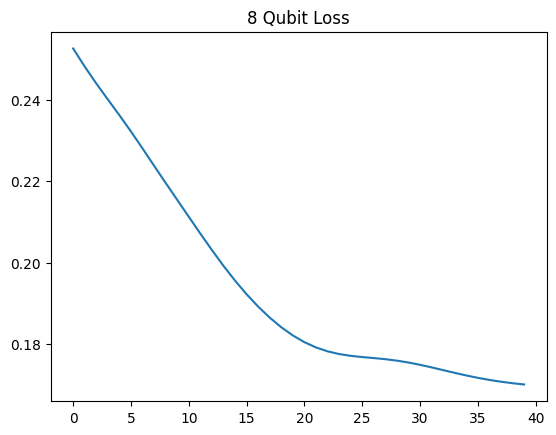

0: ──RY(2.30)───RY(1.52)──╭●───────────────────╭X──RY(-1.33)─╭●───────────────────╭X──RY(0.79)─ ···
1: ──RY(-0.50)──RY(0.43)──╰X─╭●────────────────│───RY(1.34)──╰X─╭●────────────────│───RY(2.13)─ ···
2: ──RY(-2.29)──RY(-0.27)────╰X─╭●─────────────│───RY(-0.00)────╰X─╭●─────────────│───RY(1.44)─ ···
3: ──RY(0.37)───RY(-1.63)───────╰X─╭●──────────│───RY(1.00)────────╰X─╭●──────────│───RY(1.61)─ ···
4: ──RY(-0.38)──RY(-0.50)──────────╰X─╭●───────│───RY(1.63)───────────╰X─╭●───────│───RY(0.20)─ ···
5: ──RY(0.41)───RY(-0.12)─────────────╰X─╭●────│───RY(-0.01)─────────────╰X─╭●────│───RY(0.01)─ ···
6: ──RY(-1.53)──RY(-0.53)────────────────╰X─╭●─│───RY(-1.55)────────────────╰X─╭●─│───RY(-1.79) ···
7: ──RY(-1.03)──RY(-0.01)───────────────────╰X─╰●──RY(1.72)────────────────────╰X─╰●──RY(1.68)─ ···

0: ··· ─╭●───────────────────╭X─┤  <Z>
1: ··· ─╰X─╭●────────────────│──┤     
2: ··· ────╰X─╭●─────────────│──┤     
3: ··· ───────╰X─╭●──────────│──┤     
4: ··· ──────────╰X─╭●───────│──┤     
5: ·

In [58]:
acc8,roc8,p8,pre8,rec8,f18=run_qml(8)

In [65]:
print("Classical ML:",acc_ml)

print("4 Qubits:",acc4)

print("6 Qubits:",acc6)

print("8 Qubits:",acc8)

Classical ML: 0.7162162162162162
4 Qubits: 0.7736486486486487
6 Qubits: 0.793918918918919
8 Qubits: 0.8175675675675675


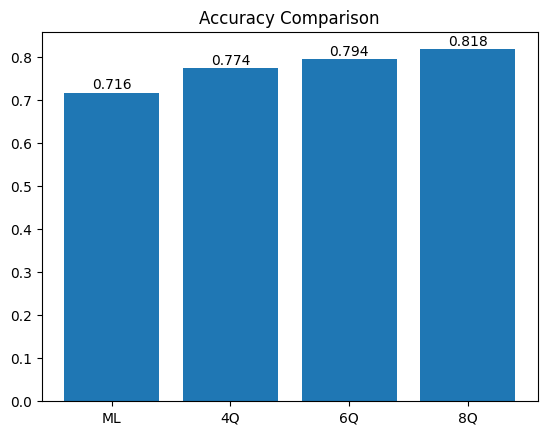

In [67]:
labels=[
"ML",
"4Q",
"6Q",
"8Q"
]

vals=[
acc_ml,
acc4,
acc6,
acc8
]

plt.bar(
labels,
vals
)

for i,v in enumerate(vals):

    plt.text(
    i,
    v+0.01,
    round(v,3),
    ha='center'
    )

plt.title(
"Accuracy Comparison"
)

plt.show()

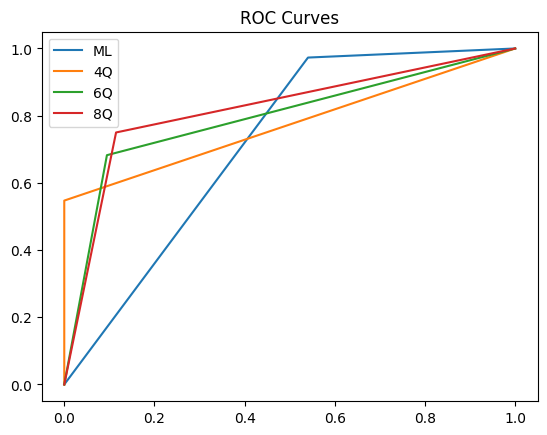

In [79]:
for pred,name in [
(pred_ml,"ML"),
(p4,"4Q"),
(p6,"6Q"),
(p8,"8Q")
]:

    fpr,tpr,_=roc_curve(
    y_test,
    pred
    )

    plt.plot(
    fpr,
    tpr,
    label=name
    )

plt.legend()

plt.title(
"ROC Curves"
)

plt.show()

In [80]:
def show_cm(pred,title):

    cm=confusion_matrix(
    y_test,
    pred
    )

    plt.imshow(cm)

    plt.title(title)

    for i in range(2):
        for j in range(2):

            plt.text(
            j,i,
            str(cm[i,j]),
            ha='center'
            )

    plt.show()

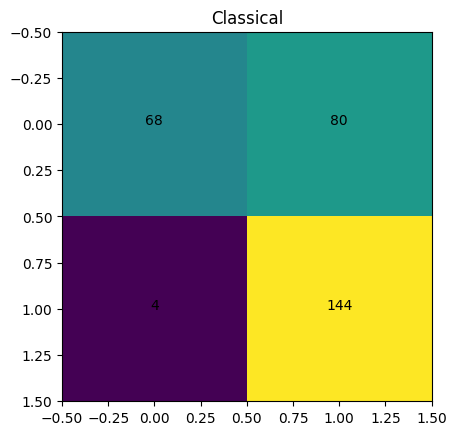

In [81]:

show_cm(
pred_ml,
"Classical"
)

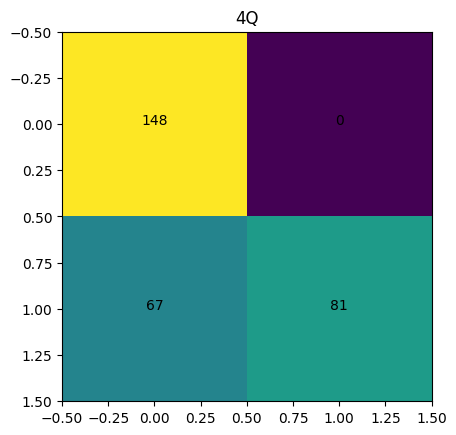

In [82]:
show_cm(
p4,
"4Q"
)

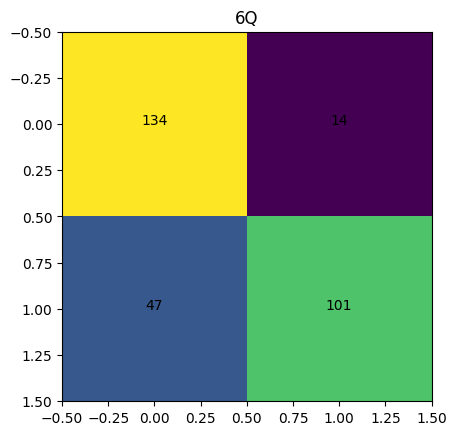

In [84]:
show_cm(
p6,
"6Q"
)


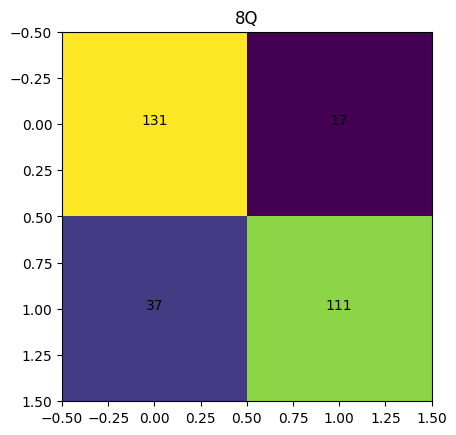

In [85]:
show_cm(
p8,
"8Q"
)

In [86]:
results = pd.DataFrame({

"Model":[
"Classical ML",
"4 Qubits",
"6 Qubits",
"8 Qubits"
],

"Accuracy":[
acc_ml,
acc4,
acc6,
acc8
],

"Precision":[
precision_score(y_test,pred_ml),
pre4,
pre6,
pre8
],

"Recall":[
recall_score(y_test,pred_ml),
rec4,
rec6,
rec8
],

"F1-Score":[
f1_score(y_test,pred_ml),
f14,
f16,
f18
]

})

print(results.round(4))

          Model  Accuracy  Precision  Recall  F1-Score
0  Classical ML    0.7162     0.6429  0.9730    0.7742
1      4 Qubits    0.7736     1.0000  0.5473    0.7074
2      6 Qubits    0.7939     0.8783  0.6824    0.7681
3      8 Qubits    0.8176     0.8672  0.7500    0.8043
